# Packages

In [33]:
import sys
sys.path.append('/home/boscoll/github/ReCAST/code')
sys.path.append('/home/boscoll/github/CDKPredict/code')
from ReCAST import ReCAST
import matplotlib as mpl
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.multitest import fdrcorrection
from sklearn.metrics import cohen_kappa_score
from helper_functions import *
from pathlib import Path
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = ['Helvetica']
from matplotlib import font_manager
font_manager.fontManager.addfont("/home/boscoll/Helvetica.ttc")

In [2]:
palette = {'high':'#FF3030', 'intermediate':'#EEB422', 'low':'#228B22'}

# Data load

In [3]:
project_path = Path('/home/boscoll/Projects/cdk_predict')
train_test_split = project_path / 'data/development_cohort/train_test_split/genomic_train_test_split_msk_final'
clinical_path = project_path / 'data/development_cohort/clinical/clinical_msk_final.csv'


with open(train_test_split, 'rb') as f:
    X_genomic_train, X_genomic_test, y_train, y_test = pickle.load(f)
y_train = y_train[['Time', 'Event']].copy()

clinical = pd.read_csv(clinical_path, index_col=0)

#merged clinicogenomic
X_clinicogenomic_train = pd.concat([X_genomic_train, clinical.loc[lambda x: x.index.isin(X_genomic_train.index)]], axis=1)
X_clinicogenomic_test = pd.concat([X_genomic_test, clinical.loc[lambda x: x.index.isin(X_genomic_test.index)]], axis=1)
X_clinicogenomic_train = X_clinicogenomic_train.reindex(y_train.index)
X_clinicogenomic_test = X_clinicogenomic_test.reindex(y_test.index)

#from the clinical only dataframe, remove the 'met_sample' variable
X_clinical_train = clinical.loc[X_genomic_train.index].copy()
X_clinical_test = clinical.loc[X_genomic_test.index].copy()
X_clinical_train.drop(columns='met_sample', inplace=True)
X_clinical_test.drop(columns='met_sample', inplace=True)

In [4]:
#load clinicogenomic model developed on the train
CDKPredict =ReCAST.load_model('/home/boscoll/Projects/cdk_predict/results/models_selection/models/CDKPredict_train_final.pkl')

#load clinical model developed on the train
ReCAST_clin = ReCAST.load_model('/home/boscoll/Projects/cdk_predict/results/models_selection/models/ReCAST_clin_train_final.pkl') 

#load genomic model developed on the train
ReCAST_genomics = ReCAST.load_model('/home/boscoll/Projects/cdk_predict/results/models_selection/models/ReCAST_genomics_train_final.pkl')

# Train set

## Clinical only and Genomic only model

**Time dependent AUC of integrating the different variables together compared to standalone biomarkers**

***Clinical model***

In [5]:
variables = X_clinical_train.loc[:, lambda x: x.columns.isin(ReCAST_clin.coefs_.index.tolist())].merge(y_train, left_index=True, right_index=True, how = 'right').pipe(univariable_cox).query('p < 0.05').index.tolist()

PFS = ReCAST_clin.risk_scores_train.apply(lambda x: x / 10).to_frame('ReCAST_clinical_score').merge(y_train, left_index=True, right_index=True, how='inner')\
.merge(X_clinical_train[variables], left_index=True, right_index=True, how='inner')

**Extended Data Fig. 4a**

/home/boscoll/github/CDKPredict/code/helper_functions.py:137: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


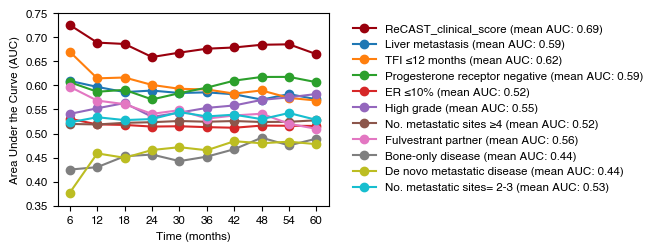

In [9]:
risk_scores = [PFS[i].values for i in PFS.columns if i not in ['Time', 'Event']]
PFS.columns = ['Progesterone receptor negative' if i == 'pr_neg' else
                      'No. metastatic sites= 2-3' if i == 'nr_mets_2_3' else 
                   'No. metastatic sites ≥4' if i == 'nr_mets_4' else 
                   'De novo metastatic disease' if i == 'de_novo_met' else 
                   'TFI ≤12 months' if i == 'tfi_under_12months' else 
                   'Bone-only disease' if i == 'bone_only' else 
                   'Liver metastasis' if i == 'liver' else 
                   'Central nervous system metastasis' if i == 'snc' else 
                   'Fulvestrant partner' if i == 'fulvestrant' else 
                   'Age at diagnosis ≤50' if i == 'age_invasive_under_50' else
                   'Age at metastatic diagnosis ≤50' if i == 'age_met_under_50' else 
                   'High grade' if i == 'high_grade' else 
                   'Metastatic sample' if i == 'met_sample' else 
                   'ER 11-80%' if i == 'er_11_80' else 
                   'No. metastatic sites' if i == 'nr_mets_tot' else
                   'CDKPredict clinical score' if i == 'CDKPredict_clinical_score' else
                   'ER ≤10%' if i == 'er_10' else i for i in PFS.columns]


plot_time_dependent_auc_from_scores(risk_scores, 
                                    [col for col in PFS.columns if col not in ['Time', 'Event']], 
                                    y_forSurv(PFS[['Time', 'Event']]), 
                                    y_forSurv(PFS[['Time', 'Event']]), 
                                    times=np.arange(6, 61, 6), 
                                    ylim=(0.35, 0.75),
                                    grid = False,
                                    figsize=(3.5,2.5),
                                    legend_out=True,     
                                    fontsize_small = True,
                                    palette = {f'{var}':f'{col}' for var, col in zip(PFS.columns, ['#99000d', sns.color_palette('Set2', n_colors=len(PFS.columns))])},                                                              
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/clinical_only_auc.pdf'
                                    )

**Fig. 2f**

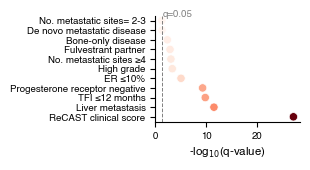

In [15]:
res = X_clinical_train.loc[:, lambda x: x.columns.isin(ReCAST_clin.coefs_.index.tolist())]\
.merge(ReCAST_clin.risk_scores_train.apply(lambda x: x / 10).to_frame('ReCAST_clinical_score'), left_index=True, right_index=True)\
    .merge(y_train, left_index=True, right_index=True, how = 'right').pipe(univariable_cox).assign(fdr = lambda x: fdrcorrection(x.p)[1]).query('fdr < 0.1')
res.index = ['Progesterone receptor negative' if i == 'pr_neg' else
                      'No. metastatic sites= 2-3' if i == 'nr_mets_2_3' else 
                   'No. metastatic sites ≥4' if i == 'nr_mets_4' else 
                   'De novo metastatic disease' if i == 'de_novo_met' else 
                   'TFI ≤12 months' if i == 'tfi_under_12months' else 
                   'Bone-only disease' if i == 'bone_only' else 
                   'Liver metastasis' if i == 'liver' else 
                   'Central nervous system metastasis' if i == 'snc' else 
                   'Fulvestrant partner' if i == 'fulvestrant' else 
                   'Age at diagnosis ≤50' if i == 'age_invasive_under_50' else
                   'Age at metastatic diagnosis ≤50' if i == 'age_met_under_50' else 
                   'High grade' if i == 'high_grade' else 
                   'Metastatic sample' if i == 'met_sample' else 
                   'ER 11-80%' if i == 'er_11_80' else 
                   'No. metastatic sites' if i == 'nr_mets_tot' else
                   'ReCAST clinical score' if i == 'ReCAST_clinical_score' else
                   'ER ≤10%' if i == 'er_10' else i for i in res.index]
#dot plot 
res[f'-log$_{{10}}$(q-value)'] = -np.log10(res['fdr'])
res[f'log$_{{2}}$(Hazard ratio)'] = np.log2(res['HR'])
res = res.sort_values(f'-log$_{{10}}$(q-value)', ascending=True)
res.reset_index(inplace = True)
plt.figure(figsize=(3.2, 1.8))
sns.scatterplot(data=res, x=f'-log$_{{10}}$(q-value)', y='index', hue=f'-log$_{{10}}$(q-value)', palette='Reds', legend=False)
plt.xlabel(f'-log$_{{10}}$(q-value)', fontsize = 'small')
plt.xticks(fontsize = 7)
plt.ylabel('')
plt.title('')
plt.yticks(fontsize = 7)
plt.axvline(x=-np.log10(0.05), color='grey', linestyle='--', linewidth=0.7)
plt.text(-np.log10(0.05)+0.1, plt.ylim()[1]*0.8, 'q=0.05', color='grey', fontsize=7)
sns.despine()
plt.tight_layout()
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/dotplot_clinical_features.pdf', bbox_inches = 'tight')
plt.show()


***Genomic model***

**Extended Data Fig. 4b**

/home/boscoll/github/CDKPredict/code/helper_functions.py:137: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


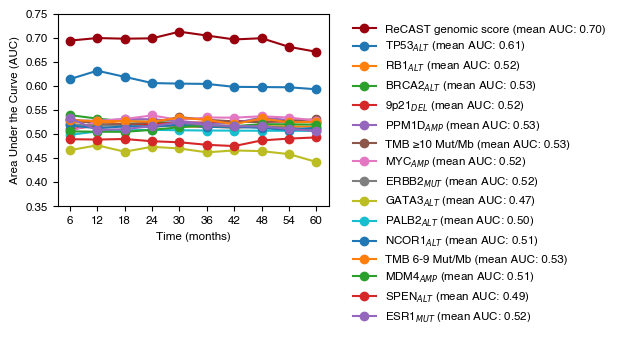

In [17]:
#first determine variables association with PFS
variables = X_genomic_train[[col for col in ReCAST_genomics.coefs_.index]].merge(y_train, left_index=True, right_index=True).pipe(univariable_cox).assign(fdr = lambda x: fdrcorrection(x.p)[1]).query('fdr < 0.1').index.tolist()
PFS = ReCAST_genomics.risk_scores_train.apply(lambda x: x / 10).to_frame('ReCAST_genomic_score').merge(y_train, left_index=True, right_index=True, how='inner')\
.merge(X_genomic_train[variables], left_index=True, right_index=True, how='inner')
PFS.columns = PFS.columns.str.replace('_tsg', '$_{{ALT}}$').str.replace('_amp', '$_{{AMP}}$').str.replace('_mut', '$_{{MUT}}$').str.replace('ReCAST_genomic_score', 'ReCAST genomic score')\
.str.replace('_deletion', '$_{{DEL}}$').str.replace('tmb_10_plus', 'TMB ≥10 Mut/Mb').str.replace('tmb_6_9', 'TMB 6-9 Mut/Mb')

risk_scores = [PFS[i].values for i in PFS.columns if i not in ['Time', 'Event']]

plot_time_dependent_auc_from_scores(risk_scores, 
                                    [col for col in PFS.columns if col not in ['Time', 'Event']], 
                                    y_forSurv(PFS[['Time', 'Event']]), 
                                    y_forSurv(PFS[['Time', 'Event']]), 
                                    times=np.arange(6, 61, 6), 
                                    ylim=(0.35, 0.75),
                                    grid = False,
                                    figsize=(3.5,2.5),
                                    legend_out=True,        
                                    fontsize_small = True,
                                    palette = {f'{var}':f'{col}' for var, col in zip(PFS.columns, ['#99000d', sns.color_palette('Set2', n_colors=len(PFS.columns))])},                                                             
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/genomic_only_auc.pdf'
                                    )

**Fig. 2g**

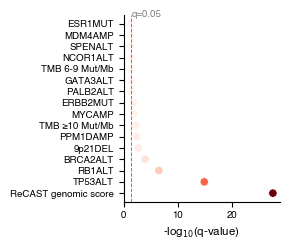

In [18]:
res = X_genomic_train.loc[:, lambda x: x.columns.isin(ReCAST_genomics.coefs_.index.tolist())]\
.merge(ReCAST_genomics.risk_scores_train.apply(lambda x: x / 10).to_frame('ReCAST_genomic_score'), left_index=True, right_index=True)\
    .merge(y_train, left_index=True, right_index=True, how = 'right').pipe(univariable_cox).assign(fdr = lambda x: fdrcorrection(x.p)[1]).query('fdr < 0.1')
res.index = res.index.str.replace('_tsg', 'ALT').str.replace('_amp', 'AMP').str.replace('_mut', 'MUT').str.replace('ReCAST_genomic_score', 'ReCAST genomic score')\
.str.replace('_deletion', 'DEL').str.replace('tmb_10_plus', 'TMB ≥10 Mut/Mb').str.replace('tmb_6_9', 'TMB 6-9 Mut/Mb')
#dot plot 
res[f'-log$_{{10}}$(q-value)'] = -np.log10(res['fdr'])
res[f'log$_{{2}}$(Hazard ratio)'] = np.log2(res['HR'])
res = res.sort_values(f'-log$_{{10}}$(q-value)', ascending=True)
res.reset_index(inplace = True)
plt.figure(figsize=(3, 2.6))
sns.scatterplot(data=res, x=f'-log$_{{10}}$(q-value)', y='covariate', hue=f'-log$_{{10}}$(q-value)', palette='Reds', legend=False)
plt.xlabel(f'-log$_{{10}}$(q-value)', fontsize = 'small')
plt.xticks(fontsize = 7)
plt.ylabel('')
plt.title('')
plt.yticks(fontsize = 7)
plt.axvline(x=-np.log10(0.05), color='grey', linestyle='--', linewidth=0.7)
plt.text(-np.log10(0.05)+0.1, plt.ylim()[1]*0.8, 'q=0.05', color='grey', fontsize=7)
sns.despine()
plt.tight_layout()
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/dotplot_genomic_features.pdf', bbox_inches = 'tight')
plt.show()


**Extended Data Fig. 4c**

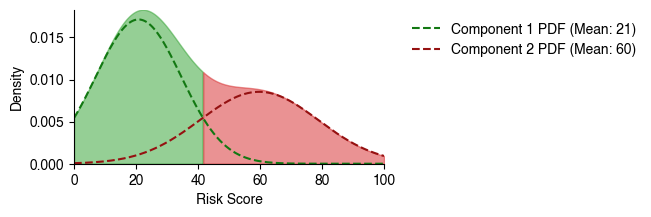

cutoff between high and low risk calculated at: 41.58.


In [19]:
ReCAST_clin.define_2_risk_groups(bins=10, figsize=(4,2), plot=True, legend=True,
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/risk_distribution_clinical.pdf'
                                    )

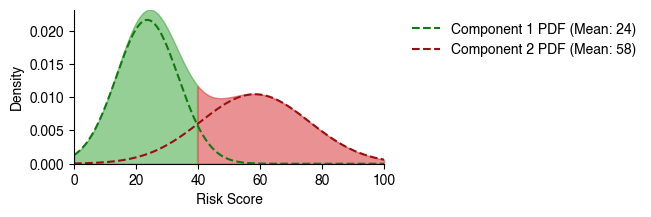

cutoff between high and low risk calculated at: 39.67.


In [20]:
ReCAST_genomics.define_2_risk_groups(bins=10, figsize=(4,2), plot=True, legend=True,
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/risk_distribution_genomic.pdf'
                                    )

In [21]:
clinical_risk = ReCAST_clin.risk_scores_train.apply(lambda x: x / 10).to_frame('ReCAST_clinical_score')
genomic_risk = ReCAST_genomics.risk_scores_train.apply(lambda x: x / 10).to_frame('ReCAST_genomic_score')
clinical_risk_class = ReCAST_clin.get_train_risk_groups_2().to_frame('ReCAST_clinical_class')
genomic_risk_class = ReCAST_genomics.get_train_risk_groups_2().to_frame('ReCAST_genomic_class')
PFS = pd.concat([
    clinical_risk,
    genomic_risk,
    clinical_risk_class,
    genomic_risk_class,
    y_train
], axis = 1)
PFS['agreement'] = ['Clinical low/Genomic low' if clinical == 'low' and genomic == 'low' else 
'Clinical high/Genomic low' if clinical == 'high' and genomic == 'low' else 
'Clinical low/Genomic high' if clinical == 'low' and genomic == 'high' else 
'Clinical high/Genomic high' if clinical == 'high' and genomic == 'high' else 'None' for clinical, genomic in zip(PFS.ReCAST_clinical_class, PFS.ReCAST_genomic_class)
]

# # save for table
# df_save = PFS.copy()
# df_save.index = df_save.index.map(key_msk.key_col)
# df_save.iloc[:, :2] = df_save.iloc[:, :2] * 10
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/risk_scores_clinical_genomic.xlsx', index=True)

In [23]:
PFS['ReCAST_clinical_class'] = PFS['ReCAST_clinical_class'].astype('category').cat.reorder_categories(['low', 'high'])
PFS['ReCAST_genomic_class'] = PFS['ReCAST_genomic_class'].astype('category').cat.reorder_categories(['low', 'high'])
PFS['agreement'] = PFS['agreement'].astype('category').cat.reorder_categories(['Clinical low/Genomic low', 'Clinical high/Genomic low', 'Clinical low/Genomic high', 'Clinical high/Genomic high'])

**Fig. 2h and Extended Data Fig. 4e**

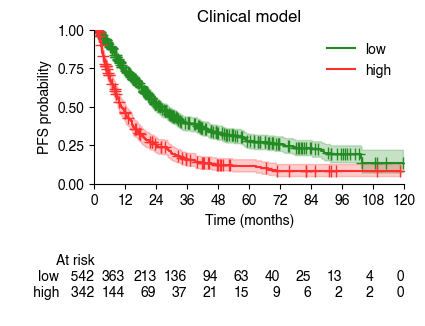

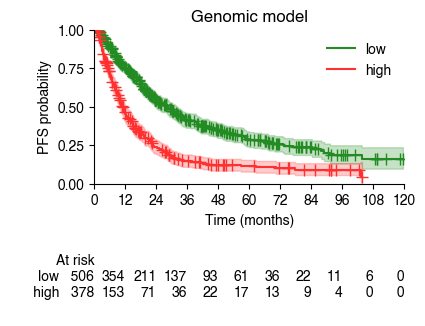

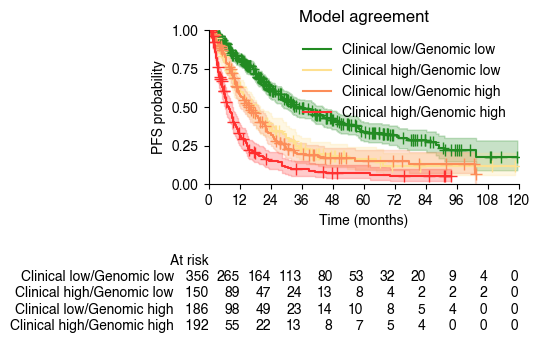

In [27]:
# palette = {'high':'#FF3030', 'medium':'#EEB422', 'low':'#228B22'}
#kaplan meier genomic group
plot_kaplan_meier_risktable(PFS.sort_values('ReCAST_clinical_class'), 'ReCAST_clinical_class', upper_limit = 120, figsize=(4,2), colors = palette, 
                            ylabel='PFS probability', title = 'Clinical model', conf_intervals=True, only_risk=True,
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/clinical_model.pdf'
                            )
plot_kaplan_meier_risktable(PFS.sort_values('ReCAST_genomic_class'), 'ReCAST_genomic_class', upper_limit = 120, figsize=(4,2), colors = palette, 
                            ylabel='PFS probability', title = 'Genomic model', conf_intervals=True, only_risk=True, 
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/genomic_model.pdf'
                            )
palette_agreement = {'Clinical low/Genomic low':'#228B22', 'Clinical high/Genomic low':'#fee090', 'Clinical low/Genomic high':'#fc8d59', 'Clinical high/Genomic high':'#FF3030'}                        
plot_kaplan_meier_risktable(PFS.sort_values('agreement'), 'agreement', upper_limit = 120, figsize=(4,2), colors = palette_agreement, 
                            ylabel='PFS probability', title = 'Model agreement', conf_intervals=True, only_risk=True, 
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/discordance.pdf'
                            )

In [28]:
tab_risks = pd.crosstab(PFS['ReCAST_clinical_class'], PFS['ReCAST_genomic_class'])
tab_risks.index = ['Clinical low' if i == 'low' else 'Clinical high' for i in tab_risks.index]
tab_risks.columns = ['Genomic low' if i == 'low' else 'Genomic high' for i in tab_risks.columns]

**Fig. 2i**

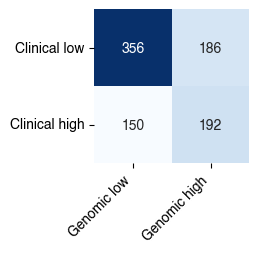

In [32]:
plt.figure(figsize=(2,2))
sns.heatmap(tab_risks, annot=True, fmt='d', cmap='Blues', cbar = False)
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha = 'right')
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/risk_agreement_heatmap.pdf', bbox_inches = 'tight')
plt.show()

**Extended Data Fig. 4d**

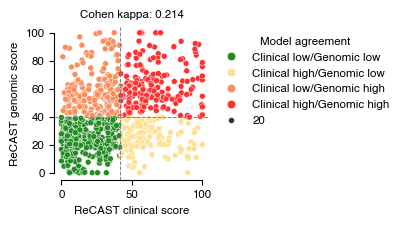

In [35]:
#scatterplot of risk scores
plt.figure(figsize=(2,2))
sns.scatterplot(data=PFS.assign(ReCAST_clinical_score = lambda x: x.ReCAST_clinical_score * 10, ReCAST_genomic_score = lambda x: x.ReCAST_genomic_score * 10), 
                x='ReCAST_clinical_score', y='ReCAST_genomic_score', hue='agreement', palette=palette_agreement, size = 20)
plt.axvline(x=ReCAST_clin.cutoff_, color='grey', linestyle='--', linewidth=0.7)
plt.axhline(y=ReCAST_genomics.cutoff_, color='grey', linestyle='--', linewidth=0.7)
legend = plt.legend(title='Model agreement', fontsize='small', title_fontsize='small',
                    loc='upper left', bbox_to_anchor=(1, 1), frameon=False)
legend.get_title().set_fontweight('bold')
plt.xlabel('ReCAST clinical score', fontsize = 'small')
plt.ylabel('ReCAST genomic score', fontsize = 'small')
plt.tick_params(labelsize = 'small')
plt.title(f"Cohen kappa: {cohen_kappa_score(PFS['ReCAST_clinical_class'].astype('category').cat.codes, PFS['ReCAST_genomic_class'].astype('category').cat.codes):.3f}", fontsize = 'small')
plt.gca().title.set_fontweight('bold')
sns.despine(trim=True)
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/clinical_genomic_risk_scatter.pdf', bbox_inches = 'tight')
plt.show()

In [38]:
PFS['ReCAST_clinical_class'] = PFS['ReCAST_clinical_class'].astype('category').cat.reorder_categories(['low', 'high'], ordered=True)
PFS['ReCAST_genomic_class'] = PFS['ReCAST_genomic_class'].astype('category').cat.reorder_categories(['low', 'high'], ordered=True)
res = PFS[['ReCAST_clinical_class', 'ReCAST_genomic_class', 'Time', 'Event']].pipe(cox_regression)
res

,hazard_ratio,ci_lower_95,ci_upper_95,p_value,log2_p_value
covariate,,,,,
ReCAST_genomic_class[T.high],2.0000,1.6985,2.3550,9.223781e-17,-53.2674
ReCAST_clinical_class[T.high],1.8928,1.6078,2.2284,1.827419e-14,-45.6372


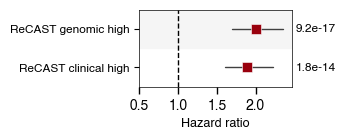

In [39]:
plot_df = res.reset_index()
plot_df.sort_values('hazard_ratio', ascending = False, inplace=True)

plot_df['covariate'] = ['ReCAST clinical high' if i == 'ReCAST_clinical_class[T.high]' else
                      'ReCAST genomic high' if i == 'ReCAST_genomic_class[T.high]' else 
                    i  for i in plot_df['covariate']]

# position and palette
ypos = np.arange(len(plot_df))  # one y per row
plot_df['ypos'] = ypos

fig, ax = plt.subplots(figsize=(2.2,1))

# light alternating background bands 
for i in range(0, len(plot_df), 4):
    ax.axhspan(i-0.5, i+0.5, color='0.96', zorder=0)
ax.axvline(1, ls='--', lw=1, color='black', zorder=1)


for _, r in plot_df.iterrows():
    # CI bar
    ax.plot([r['ci_lower_95'], r['ci_upper_95']], [r['ypos'], r['ypos']],
            color='0.25', lw=1, solid_capstyle='round', zorder=2)
    # square marker at HR
    ax.scatter(r['hazard_ratio'], r['ypos'],
               s=50, marker='s',
               color= '#99000d',
               edgecolor='white', linewidth=0.4,
               zorder=3)

# y axis
ax.set_yticks(ypos)
ax.set_ylim(-0.5, len(plot_df)-0.5)
ax.set_yticklabels(plot_df['covariate'], fontsize=8.5)
ax.invert_yaxis()  
ax.grid(False)


# x axis
ax.tick_params(axis='x',
               which='major',
               bottom=True, top=False,    
               length=5, width=1,         
               direction='out')
ax.set_xlabel('Hazard ratio', fontsize=9)
ax.set_xticks([0.5, 1, 1.5, 2]) 

# major axis
ax.spines['bottom'].set_visible(True)
ax.spines['bottom'].set_color('black')
ax.spines['bottom'].set_linewidth(0.5)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['top'].set_linewidth(0.5)
ax.spines['right'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)
ax.spines['left'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['top'].set_color('black')

# x range
xmin = max(0.1, plot_df['ci_lower_95'].min()*0.95)
xmax = plot_df['ci_upper_95'].max()*1.05
ax.set_xlim(0.5, xmax)
ax.set_xlabel('Hazard ratio')
ax.set_ylabel('')

# p values
for _, r in plot_df.iterrows():
    ax.text(xmax*1.02, r['ypos'], f"{r['p_value']:.2g}",
            va='center', ha='left', fontsize=8.5,
            fontweight='bold' if r['p_value'] < 0.05 else 'normal',
            )

plt.subplots_adjust(right=0.82)


import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none' 
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/multivariable_clinical_genomic.pdf', bbox_inches='tight')
plt.show()


## Clinicogenomic model

**Extended Data Fig. 4f**

cutoff between low and intermediate risk calculated at: 30.93, cutoff between intermediate and high risk calculated at: 59.30


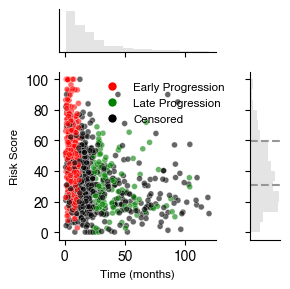

In [41]:
CDKPredict.define_3_risk_groups()
plot_df = CDKPredict.risk_scores_train.to_frame().merge(y_train, left_index=True, right_index=True, how='left')
plot_df = plot_df.assign(group = ['early' if t <= 12 and e == 1 else 'late' if t >= 24 and e ==1 else 'censored' for t, e in zip(plot_df['Time'], plot_df['Event'])])
colors = {'early':'red', 'late':'green', 'censored':'black'}
g = sns.JointGrid(data=plot_df, x='Time', y='risk_score', height=3, ratio = 3)
sns.scatterplot(data=plot_df, x='Time', y='risk_score', hue='group', palette=colors, alpha=0.6, size = 15, ax=g.ax_joint)
g.plot_marginals(sns.histplot, bins=15, color='#d9d9d9', alpha=0.7, edgecolor=None)
g.set_axis_labels('Time (months)', 'Risk Score', fontsize = 'small')
plt.axhline(CDKPredict.cutoff_low_intermediate_, color='#969696', linestyle='--', label='Cutoff low-intermediate', linewidth=1.5)
plt.axhline(CDKPredict.cutoff_intermediate_high_, color='#969696', linestyle='--', label='Cutoff intermediate-high', linewidth=1.5)
plt.xticks(np.arange(0, 121, 12))
g.ax_joint.legend(loc='upper right', fontsize = 'small', frameon=False, bbox_to_anchor=(1.12, 1), handles=[plt.Line2D([0], [0], marker='o', color='w', label='Early Progression', markerfacecolor='red', markersize=7),
                                                                                                                      plt.Line2D([0], [0], marker='o', color='w', label='Late Progression', markerfacecolor='green', markersize=7),
                                                                                                                      plt.Line2D([0], [0], marker='o', color='w', label='Censored', markerfacecolor='black', markersize=7)])
sns.despine()
plt.tick_params(labelsize = 'small')
plt.tight_layout()
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/risk_score_scatter.pdf', bbox_inches='tight')
plt.show()

In [42]:
risk_scores = CDKPredict.risk_scores_train.to_frame().merge(y_train, left_index=True, right_index=True, how='inner')
#divide 10 bins of risk scores
risk_scores['risk_bin'] = pd.qcut(risk_scores['risk_score'], q=10, labels=False)
risk_scores['risk_bin'] = risk_scores['risk_bin'] + 1
risk_scores = risk_scores.sort_values('risk_bin')

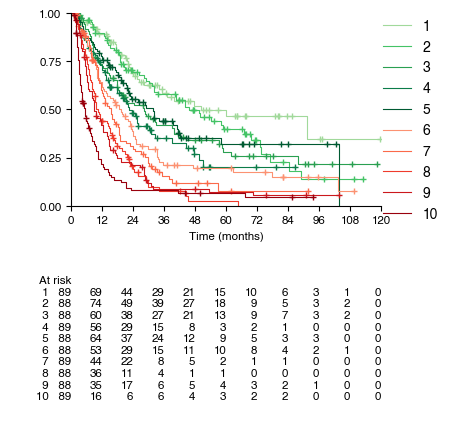

In [44]:
palette_km = {10:'#99000d', 9:'#cb181d', 8:'#ef3b2c', 7:'#fb6a4a', 6:'#fc9272', 5:'#005a32', 4:"#0B7C49", 3:"#2aa051", 2:"#44c366", 1:'#a1d99b'}
plot_kaplan_meier_risktable(risk_scores, 'risk_bin', colors=palette_km, figsize=(4,2.5), only_risk=True, legend_out=True, upper_limit=120, fontsize_small=True,
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/risk_bin_kaplan_meier.pdf'
                            )

**Fig. 2m**

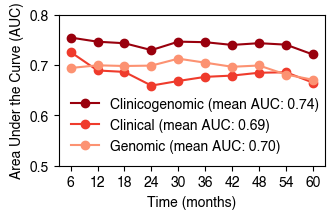

In [45]:
#genomic vs clinical vs clinicogenomic models
palette_model = {'Clinicogenomic':'#99000d', 'Clinical':'#ef3b2c', 'Genomic':'#fc9272'}
risk_scores = []
risk_scores.append(CDKPredict.risk_scores_train.reindex(y_train.index).values)
risk_scores.append(ReCAST_clin.risk_scores_train.reindex(y_train.index).values)
risk_scores.append(ReCAST_genomics.risk_scores_train.reindex(y_train.index).values)
plot_time_dependent_auc_from_scores(risk_scores, 
                                    ['Clinicogenomic', 'Clinical', 'Genomic'], 
                                    y_forSurv(y_train), 
                                    y_forSurv(y_train), 
                                    times=np.arange(6, 61, 6), 
                                    grid = False,
                                    figsize=(3.45,2.3),
                                    ylim=(0.5, 0.8), 
                                    palette = palette_model,
                                    # fontsize_small = True,
                                    # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/models_omics_comparison_AUC.pdf'
                                    )

In [46]:
print(f'clinicogenomic_model.calculate_train_cindex(y_train): {CDKPredict.calculate_train_cindex(y_train)}')
print(f'clinical_model.calculate_train_cindex(y_train): {ReCAST_clin.calculate_train_cindex(y_train)}')
print(f'genomic_model.calculate_train_cindex(y_train): {ReCAST_genomics.calculate_train_cindex(y_train)}')

clinicogenomic_model.calculate_train_cindex(y_train): 0.6840388044702644
clinical_model.calculate_train_cindex(y_train): 0.6430241608401943
genomic_model.calculate_train_cindex(y_train): 0.6443722680713693


**Fig. 2n**

/tmp/ipykernel_2022791/86755914.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=plot_df, x='group', y='c_index', palette=palette_model, size=3, jitter=True)


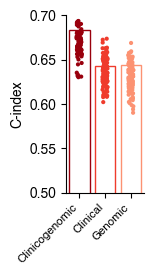

In [48]:
pd.concat([
pd.Series(CDKPredict.calculate_train_cindex(y_train), name='Clinicogenomic'), 
pd.Series(ReCAST_clin.calculate_train_cindex(y_train), name='Clinical'),
pd.Series(ReCAST_genomics.calculate_train_cindex(y_train), name='Genomic')
], axis=1).T\
.plot.bar(y=0, legend=False, edgecolor=['#99000d', '#ef3b2c', '#fc9272'], color = 'white', figsize=(1,2.3), width=0.8)
plt.ylim(0.5, 0.70)

plot_df = pd.concat([
CDKPredict.cindex_models.to_frame().assign(group = 'Clinicogenomic'), 
ReCAST_clin.cindex_models.to_frame().assign(group = 'Clinical'),
ReCAST_genomics.cindex_models.to_frame().assign(group = 'Genomic')], axis=0)

sns.stripplot(data=plot_df, x='group', y='c_index', palette=palette_model, size=3, jitter=True)
plt.xlabel('')
plt.ylabel('C-index')
plt.xticks(fontsize = 'small', rotation = 45, ha='right')
plt.tick_params()
sns.despine()

# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/train_cindex_comparison.pdf', bbox_inches='tight')
plt.show()

**Fig. 2o**

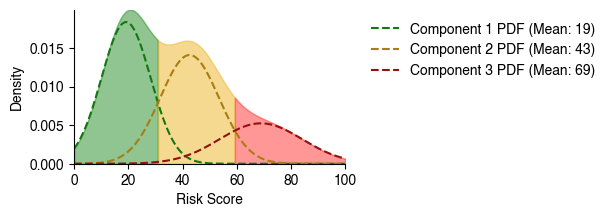

cutoff between low and intermediate risk calculated at: 30.93, cutoff between intermediate and high risk calculated at: 59.30


In [49]:
CDKPredict.define_3_risk_groups(plot=True, bins= 15, figsize=(3.5,2), legend=True,
                                        #   save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/risk_score_distribution_train_clinicogenomic.pdf'
                                          )                                        

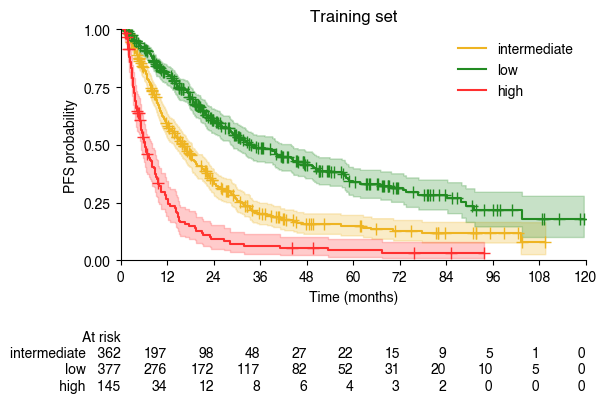

In [52]:
palette = {'high':'#FF3030', 'intermediate':'#EEB422', 'low':'#228B22'}
PFS = pd.DataFrame(CDKPredict.get_train_risk_groups_3()).merge(y_train, left_index=True, right_index=True)
PFS.pipe(plot_kaplan_meier_risktable, 'risk_group', upper_limit = 120, figsize=(6,3), colors = palette, 
         title = 'Training set', conf_intervals=True, only_risk = True, ylabel='PFS probability', 
        #  save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/train_groups_km.pdf'
         ) 

In [ ]:
# #Save for table
# df_save =  clinicogenomic_model.risk_scores_train.to_frame().join(PFS)
# df_save.index = df_save.index.map(key_msk.key_col)
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/risk_scores_clinicogenomic.xlsx', index=True)


# Internal hold-out test set

In [55]:
PFS_test = CDKPredict.predict(X_clinicogenomic_test, classify=True, groups = 3)
PFS_test = pd.DataFrame(PFS_test).merge(y_test, left_index=True, right_index=True)

Activated the classify option, returning risk groups instead of continuous risk scores.


In [64]:
# #save table
# df_save = clinicogenomic_model.predict(X_test, classify=False).to_frame().join(PFS_test)
# df_save.index = df_save.index.map(key_msk.key_col)
# df_save.to_excel('/home/boscoll/Projects/cdk_predict/results/tables/risk_scores_clinicogenomic_msk_validation.xlsx', index=True)

**Extended Data Fig. 4h**

The option `classify` is set to False, returning continuous risk scores.


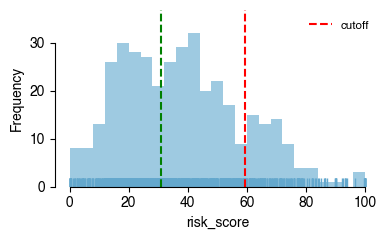

In [57]:
CDKPredict.predict(X_clinicogenomic_test).plot.hist(bins=25, figsize=(4,2.5), color ='#9ecae1', legend = False)
sns.rugplot(CDKPredict.risk_scores_train, height=0.05, color="#64a8cd", legend=False)
cutoff_line = plt.axvline(CDKPredict.cutoff_low_intermediate_, color='green', linestyle='--', label='cutoff')
cutoff_line = plt.axvline(CDKPredict.cutoff_intermediate_high_, color='red', linestyle='--', label='cutoff')
plt.legend(fontsize = 'small', frameon=False, handles = [cutoff_line], labels = ['cutoff'])
plt.title('', fontweight='bold')
sns.despine(trim=True)
plt.tight_layout()
mpl.rcParams['pdf.fonttype'] = 42
# plt.savefig('/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/clinicogenomic_model_msk_risk_score_distribution.pdf')
plt.show()

**Fig. 2r**

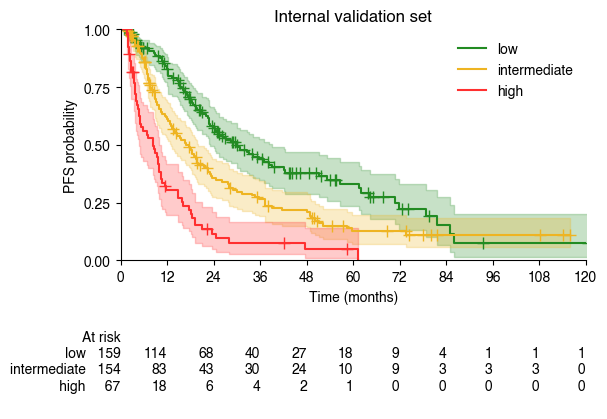

In [58]:
plot_kaplan_meier_risktable(PFS_test, 'risk_group', upper_limit = 120, figsize=(6,3), colors = palette, 
                            ylabel='PFS probability', title = 'Internal validation set', conf_intervals=True, only_risk=True,
                            # save = '/scratch/razavip/boscoll/cdk_predict/results/images/paper_figures/cdkpredict_msk_cohort/test_groups_km.pdf'
                            )